In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
A = pd.read_pickle("indv_hashtag_simulations.pkl", compression="bz2")

In [3]:
P = A.drop_duplicates("hash2").copy()

In [4]:
%%time
def get_set_up(p):
    adj, inf_s, deg = p
#     overlap  = ( (adj * inf_s).sum(axis=1) != deg ).sum()
    overlap  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s).sum() # those who are infected and lie on the frontier
    vax_count = inf_s.sum()
    ht2_count = ((inf_s == 0).sum() + overlap)
    vax_div_ab = overlap / vax_count 
    h2_div_ab  = overlap / ht2_count
    return overlap, vax_count, ht2_count, vax_div_ab, h2_div_ab 

P["overlap"] = P.params.apply(get_set_up)

CPU times: user 3.41 s, sys: 1.51 s, total: 4.92 s
Wall time: 6.59 s


In [5]:
def get_network(adj):
    G = nx.from_numpy_array(adj)
    return nx.radius(G)

In [147]:
# # # Test is fine
# p = P.params.iloc[6]
# adj, inf_s, deg = p
# overlap  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s).sum()
# vax_count = inf_s.sum()
# ht2_count = ((inf_s == 0).sum() + overlap)
# vax_div_ab = overlap / vax_count 
# h2_div_ab  = overlap / ht2_count

# overlap, vax_count, ht2_count

(545, 4967, 5897)

In [6]:
%%time
A["ts_max"]     = A.ts_dorm.apply(lambda x: x[-1])
A["ts_midstep"] = A.ts_dorm.apply(lambda x: np.searchsorted(x, (x[-1]+x[0])/2, side='right'))
A["ts_gain"]    = A.ts_dorm.apply(lambda x: x[-1] - x[0])

CPU times: user 63.8 ms, sys: 19.3 ms, total: 83.1 ms
Wall time: 89.1 ms


In [7]:
P["vax_overlap"] = P.overlap.apply(lambda x: x[3])
P["ht2_overlap"] = P.overlap.apply(lambda x: x[4])
P["viable_depth"] = P.overlap.apply(lambda x: x[2] - x[0]) #ht2 - overlap

In [8]:
# def get_num_CC(p):
#     adj, inf_s, deg = p
#     G = nx.from_numpy_array(adj)
#     overlap  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s)
    
#     CC = list( nx.connected_components(G) )
#     return len(CC)
    
def get_num_CC(p,graph="full"):
    adj, inf_s, deg = p
    G = nx.from_numpy_array(adj)
    
    frontier  = (( (adj * inf_s).sum(axis=1) != deg )*inf_s) # those who are infected and lie on the frontier
    hash2_ids =  ~p[1]
    if graph == "full":
        return len(list( nx.connected_components(G) ))
    else:
        GG = G.subgraph(np.argwhere(hash2_ids + frontier ).squeeze())
        return len(list( nx.connected_components(GG) ))


In [9]:
%%time
P["num_CC_full"] = P.params.apply(lambda p: get_num_CC(p))

CPU times: user 16 s, sys: 1.47 s, total: 17.5 s
Wall time: 18.6 s


In [10]:
%%time
P["num_CC_hashgraph"] = P.params.apply(lambda p: get_num_CC(p,"sub"))

CPU times: user 47.6 s, sys: 1.52 s, total: 49.2 s
Wall time: 50.4 s


In [11]:
%time
P["density"] = P.params.apply(lambda x: nx.density( nx.from_numpy_array(x[0])))

CPU times: user 1 µs, sys: 1e+03 ns, total: 2 µs
Wall time: 3.1 µs


In [ ]:
P

In [12]:
AA = A.merge(P[["hash2","vax_overlap","ht2_overlap","density",
                "viable_depth", "num_CC_full", "num_CC_hashgraph"]],
             left_on="hash2", right_on="hash2")
AA["perc_gain"] = AA.ts_gain / (AA.viable_depth+1)
AA = AA[AA.ht2_overlap != 1]

In [33]:
# plt.figure(figsize=(20,8))
# plt.subplot(1,2,1)
# sns.regplot(AA.vax_overlap, AA.ts_max, label="")
# plt.xlim(0,0.4)
# plt.title("a) Overlap with Pro-Vax", fontsize=20)
# plt.xlabel("Percent overlap with Vaccine", fontsize=20)
# plt.ylabel("Total Diffusion", fontsize=20)
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)

# plt.subplot(1,2,2)
# sns.regplot(AA.ht2_overlap, AA.ts_max, label="", color="orange")
# plt.xlim(0,1.05)
# plt.title("b) Overlap with secondary hashtag",  fontsize=20)
# plt.xlabel("Percent overlap with second. hashtag", fontsize=20)
# plt.ylabel("Total Diffusion", fontsize=20)
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)



/Users/herbert/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

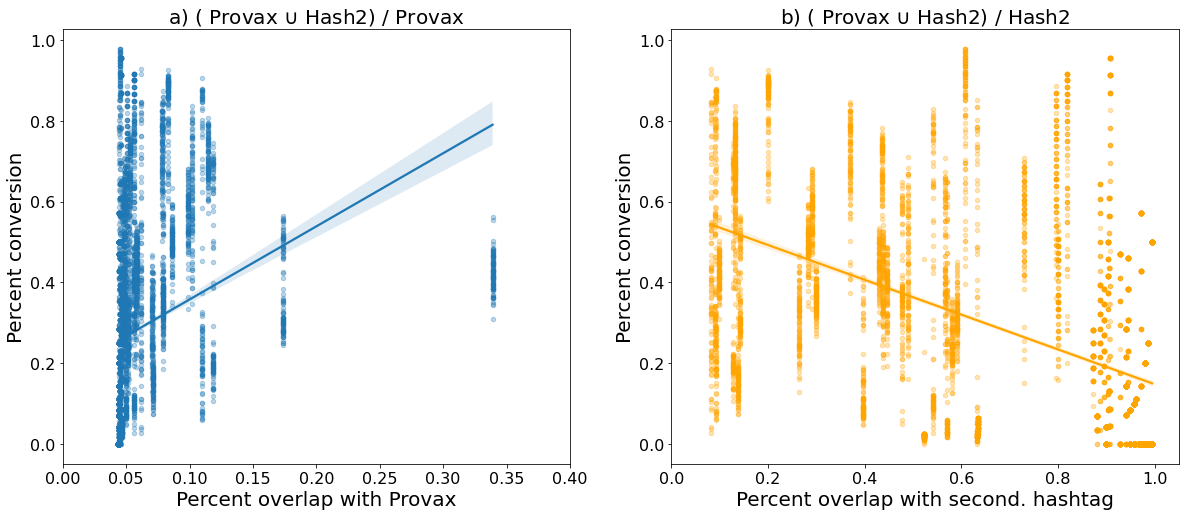

In [13]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.regplot(AA.vax_overlap, AA.perc_gain, label="",scatter_kws={'s': 20, 'alpha': 0.3})
plt.xlim(0,0.4)
plt.title(f"a) ( Provax $\cup$ Hash2) / Provax", fontsize=20)
plt.xlabel("Percent overlap with Provax", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.subplot(1,2,2)
sns.regplot(AA.ht2_overlap, AA.perc_gain, label="", color="orange",scatter_kws={'s': 20, 'alpha': 0.3})
plt.xlim(0,1.05)
plt.title("b) ( Provax $\cup$ Hash2) / Hash2",  fontsize=20)
plt.xlabel("Percent overlap with second. hashtag", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.savefig("figures/regression.png", bbox_inches="tight")

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

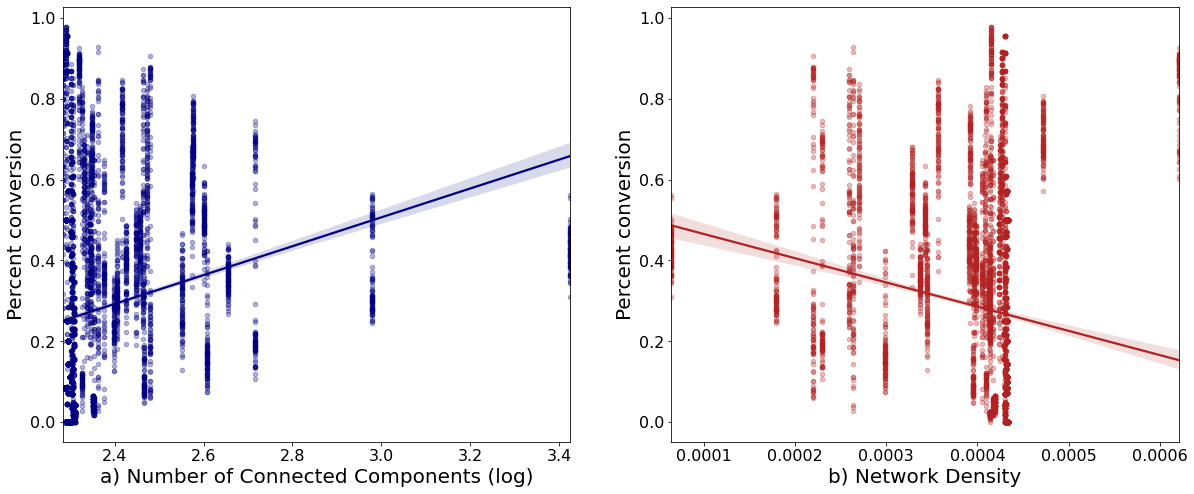

In [14]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.regplot(np.log10( AA.num_CC_hashgraph ), AA.perc_gain, color="navy", label="",scatter_kws={'s': 20, 'alpha': 0.3})
# plt.xlim(0,0.4)
# plt.title(f"a) Connected Components", fontsize=20)
plt.xlabel("a) Number of Connected Components (log)", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.subplot(1,2,2)
sns.regplot(AA.density, AA.perc_gain, label="", color="firebrick",scatter_kws={'s': 20, 'alpha': 0.3})
# plt.xlim(0,1.05)
# plt.title("b) Density",  fontsize=20)
plt.xlabel("b) Network Density", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.savefig("figures/network_regression.png", bbox_inches="tight")

In [53]:
AA['q_vax'] = pd.qcut(AA['vax_overlap'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
AA['q_ht2'] = pd.qcut(AA['ht2_overlap'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

AA['q_CC'] = pd.qcut(AA['num_CC_hashgraph'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
AA['q_dense'] = pd.qcut(AA['density'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

Text(0.5, 0, 'Percent conversion')

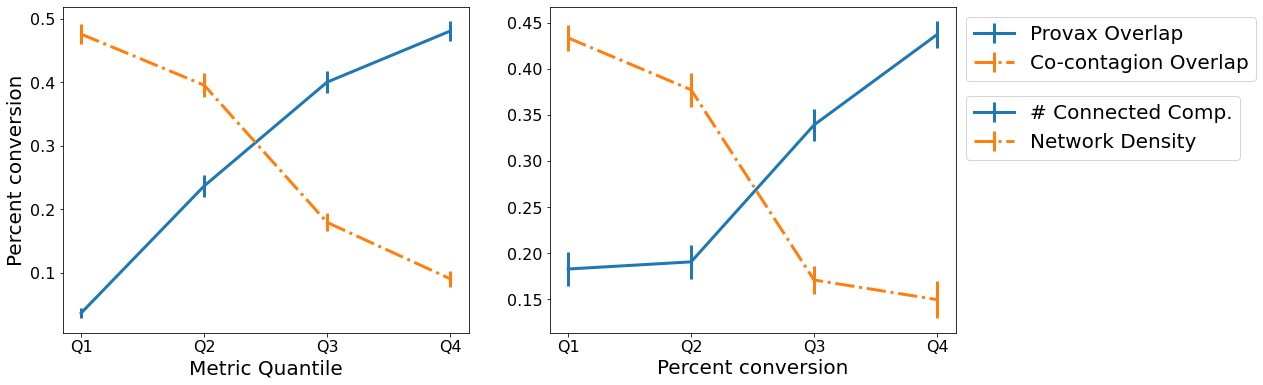

In [74]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
mu  = AA.groupby("q_vax")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_vax")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_vax, mu.perc_gain, yerr=mu.se,linewidth=3, label = "Provax Overlap")

mu  = AA.groupby("q_ht2")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_ht2")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_ht2, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="-.", label = "Co-contagion Overlap")

plt.legend(fontsize=20,loc='upper left', bbox_to_anchor=(2.2, 1))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Metric Quantile", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)

plt.subplot(1,2,2)
mu  = AA.groupby("q_CC")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_CC")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_CC, mu.perc_gain, yerr=mu.se,linewidth=3, label = "# Connected Comp.")

mu  = AA.groupby("q_dense")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_dense")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_dense, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="-.", label = "Network Density")

plt.legend(fontsize=20,loc='lower left', bbox_to_anchor=(1, 0.5))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Percent conversion", fontsize=20)

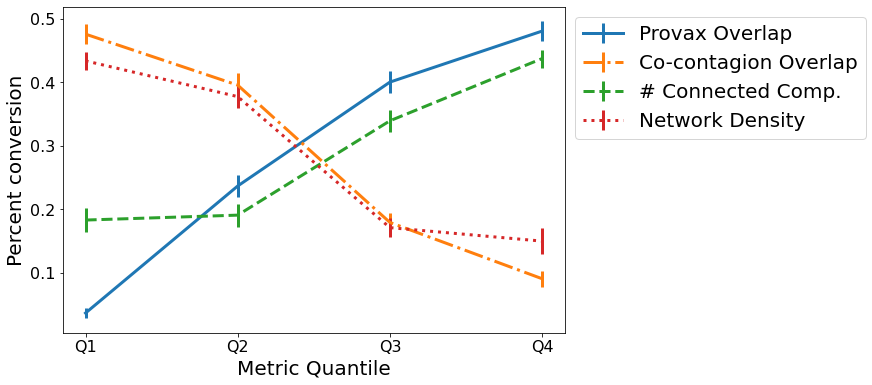

In [82]:
plt.figure(figsize=(9,6))

mu  = AA.groupby("q_vax")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_vax")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_vax, mu.perc_gain, yerr=mu.se,linewidth=3, label = "Provax Overlap")

mu  = AA.groupby("q_ht2")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_ht2")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_ht2, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="-.", label = "Co-contagion Overlap")

plt.legend(fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Metric Quantile", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)


mu  = AA.groupby("q_CC")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_CC")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_CC, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle="--", label = "# Connected Comp.")

mu  = AA.groupby("q_dense")["perc_gain"].mean().reset_index()
sig = (AA.groupby("q_dense")["perc_gain"].sem()*3)
mu["se"] = sig.values
plt.errorbar(mu.q_dense, mu.perc_gain, yerr=mu.se,linewidth=3, linestyle=":", label = "Network Density")

plt.legend(fontsize=20,loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Metric Quantile", fontsize=20)

plt.savefig("figures/conversion_yield.png", bbox_inches="tight")

/Users/herbert/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

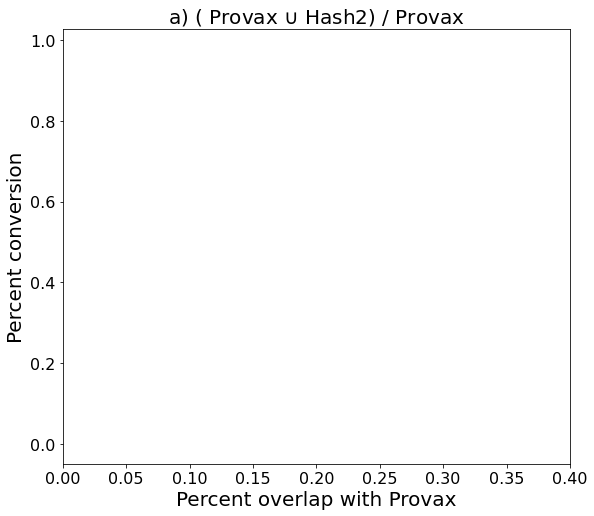

In [18]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.regplot(AA.num_CC_full, AA.perc_gain, label="",scatter_kws={'s': 20, 'alpha': 0.3})
plt.xlim(0,0.4)
plt.title(f"a) ( Provax $\cup$ Hash2) / Provax", fontsize=20)
plt.xlabel("Percent overlap with Provax", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

In [17]:
P

,hash2,params,ts_dorm,overlap,vax_overlap,ht2_overlap,viable_depth,num_CC_full,num_CC_hashgraph
0,hiv,"[[[False, True, False, False, False, False, Fa...","[5264.0, 5279.0, 5293.0, 5313.0, 5333.0, 5352....","(522, 5264, 1790, 0.09916413373860182, 0.29162...",0.099164,0.291620,1268,762,375
0,trumptrain1111,"[[[False, True, False, False, False, False, Fa...","[4639.0, 4639.0, 4639.0, 4639.0, 4639.0, 4639....","(204, 4639, 204, 0.04397499461090752, 1.0)",0.043975,1.000000,0,586,194
0,endhivepidemic,"[[[False, True, False, False, False, False, Fa...","[4650.0, 4651.0, 4651.0, 4651.0, 4651.0, 4651....","(214, 4650, 236, 0.046021505376344085, 0.90677...",0.046022,0.906780,22,588,196
0,stophivstigma,"[[[False, True, False, False, False, False, Fa...","[4642.0, 4642.0, 4642.0, 4642.0, 4642.0, 4642....","(205, 4642, 206, 0.04416199913830245, 0.995145...",0.044162,0.995146,1,588,195
0,stigma,"[[[False, True, False, False, False, False, Fa...","[4642.0, 4642.0, 4642.0, 4642.0, 4642.0, 4642....","(205, 4642, 209, 0.04416199913830245, 0.980861...",0.044162,0.980861,4,590,197
...,...,...,...,...,...,...,...,...,...
0,secondwave,"[[[False, True, False, False, False, False, Fa...","[4643.0, 4643.0, 4643.0, 4643.0, 4643.0, 4643....","(205, 4643, 214, 0.04415248761576567, 0.957943...",0.044152,0.957944,9,594,201
0,borisvoteofnoconfidence,"[[[False, True, False, False, False, False, Fa...","[4639.0, 4639.0, 4639.0, 4639.0, 4639.0, 4639....","(204, 4639, 208, 0.04397499461090752, 0.980769...",0.043975,0.980769,4,588,196
0,ebola,"[[[False, True, False, False, False, False, Fa...","[5202.0, 5230.0, 5252.0, 5273.0, 5295.0, 5310....","(406, 5202, 1099, 0.07804690503652441, 0.36942...",0.078047,0.369427,693,640,261
0,drc,"[[[False, True, False, False, False, False, Fa...","[4787.0, 4792.0, 4801.0, 4804.0, 4808.0, 4815....","(217, 4787, 357, 0.04533110507624817, 0.607843...",0.045331,0.607843,140,578,195


# Embedding

In [19]:
EE = AA.merge(E, left_on = "hash2", right_on="hashtag")

In [11]:
E = pd.read_pickle("embeddings.pkl",compression="bz2")

In [29]:
EE.groupby("hash2")[["perc_gain", "cosine_dist"]].mean().reset_index()

,hash2,perc_gain,cosine_dist
0,ai,0.704444,0.414063
1,art,0.380090,0.415042
2,asimriaz,0.000000,0.546132
3,borishasfaileduk,0.094444,0.420258
4,borisvoteofnoconfidence,0.000000,0.556427
...,...,...,...
65,video,0.373964,0.646742
66,votebymail,0.392281,0.519772
67,washyourhands,0.027010,0.603985
68,wuhancoronavirus,0.227647,0.551914


/Users/herbert/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

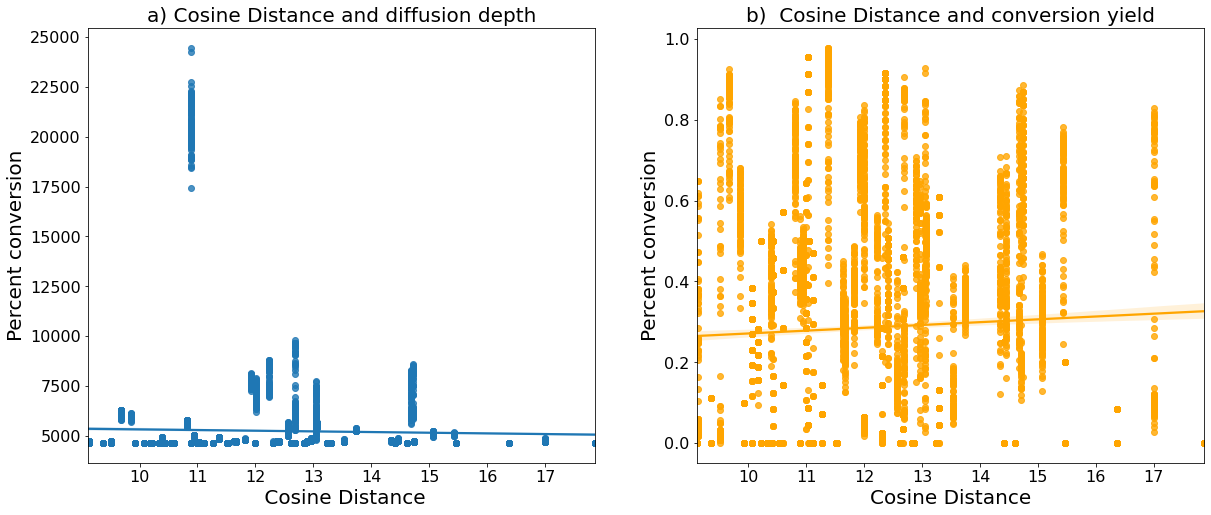

In [30]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.regplot(EE.euclid_dist, EE.ts_max, label="")
# plt.xlim(0,0.4)
plt.title("a) Cosine Distance and diffusion depth", fontsize=20)
plt.xlabel(" Cosine Distance", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.subplot(1,2,2)
sns.regplot(EE.euclid_dist, EE.perc_gain, label="", color="orange")
# plt.xlim(0,1.05)
plt.title("b)  Cosine Distance and conversion yield",  fontsize=20)
plt.xlabel("Cosine Distance", fontsize=20)
plt.ylabel("Percent conversion", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)